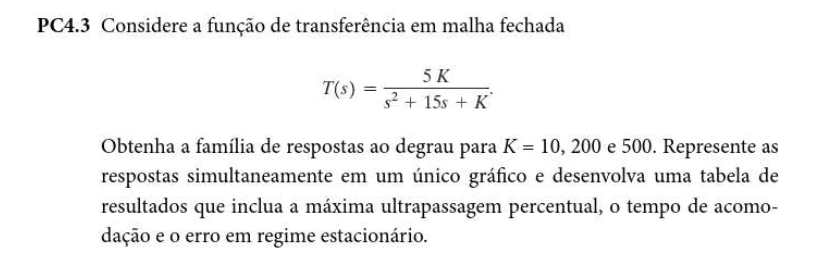

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

# Valores de K
K_values = [10, 200, 500]

# Definir as funções de transferência para cada K
# T(s) = 5K / (s^2 + 15s + K)
transfer_functions = {}
for K in K_values:
    num = [5 * K]  # Numerador: 5K
    den = [1, 15, K]  # Denominador: s^2 + 15s + K
    transfer_functions[K] = signal.TransferFunction(num, den)

print("Funções de Transferência:")
for K, tf in transfer_functions.items():
    print(f"K = {K}: T(s) = {5*K} / (s² + 15s + {K})")
    print(f"  Polos: {signal.TransferFunction(tf.num, tf.den).poles}\n")

Funções de Transferência:
K = 10: T(s) = 50 / (s² + 15s + 10)
  Polos: [-14.30073525  -0.69926475]

K = 200: T(s) = 1000 / (s² + 15s + 200)
  Polos: [-7.5+11.98957881j -7.5-11.98957881j]

K = 500: T(s) = 2500 / (s² + 15s + 500)
  Polos: [-7.5+21.06537443j -7.5-21.06537443j]



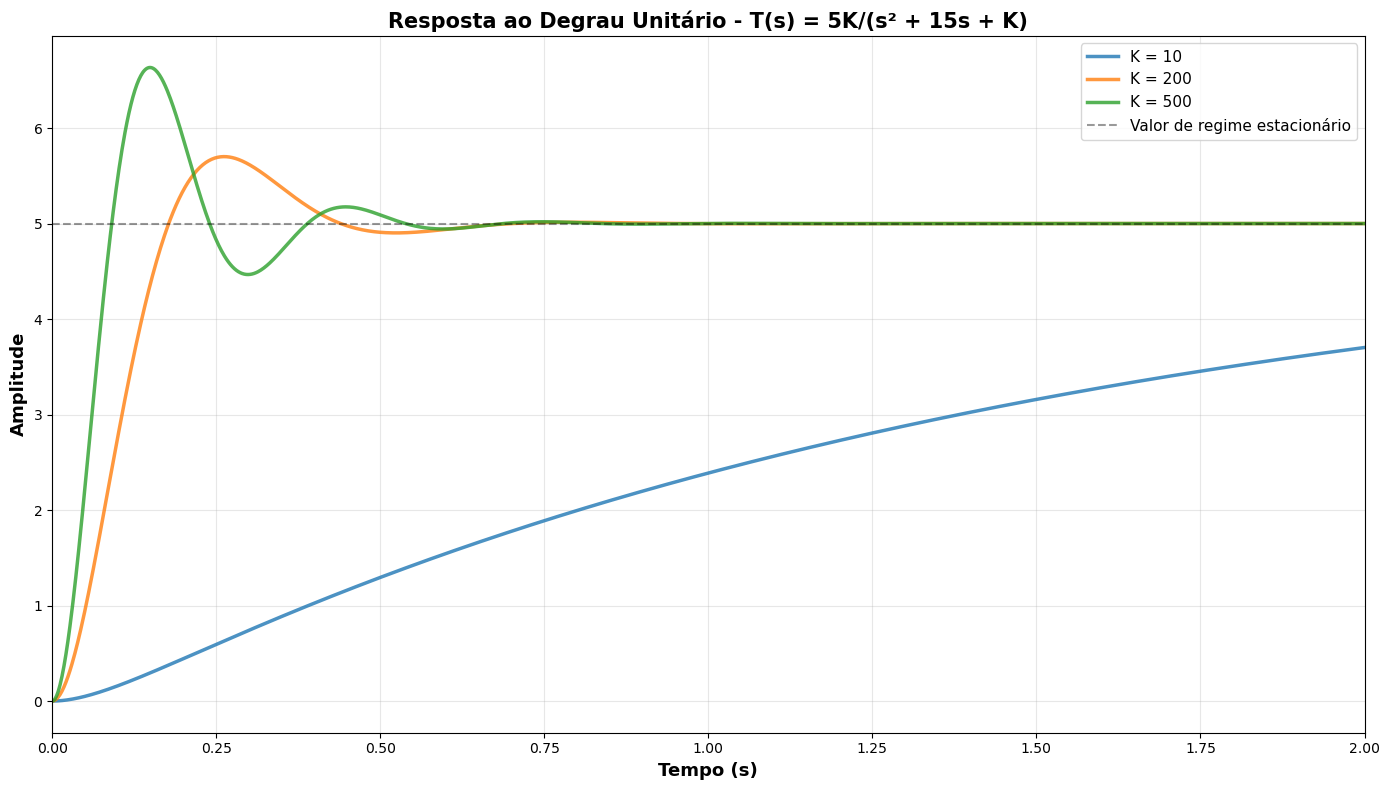


ANÁLISE DAS RESPOSTAS AO DEGRAU UNITÁRIO

Função de Transferência em Malha Fechada: T(s) = 5K / (s² + 15s + K)

  K Ganho DC Máximo Sobressinal (%) Tempo de Acomodação (s) Erro em Regime Est.
 10   4.3548                   0.00                  2.8199             -3.3548
200   5.0000                  14.01                  0.4097             -4.0000
500   5.0000                  32.67                  0.4967             -4.0000

ANÁLISE:
----------------------------------------------------------------------------------------------------

K = 10:
  • Ganho DC (y_ss): 4.3548
  • Máximo Sobressinal: 0.00%
  • Tempo de Acomodação (±2%): 2.8199 s
  • Erro em Regime Estacionário: -3.3548

K = 200:
  • Ganho DC (y_ss): 5.0000
  • Máximo Sobressinal: 14.01%
  • Tempo de Acomodação (±2%): 0.4097 s
  • Erro em Regime Estacionário: -4.0000

K = 500:
  • Ganho DC (y_ss): 5.0000
  • Máximo Sobressinal: 32.67%
  • Tempo de Acomodação (±2%): 0.4967 s
  • Erro em Regime Estacionário: -4.0000


In [3]:
# Calcular as respostas ao degrau e métricas
time = np.linspace(0, 3, 2000)  # Tempo de simulação aumentado
responses = {}
metrics = {}

fig, ax = plt.subplots(figsize=(14, 8))

for K in K_values:
    # Calcular resposta ao degrau unitário
    t, y = signal.step(transfer_functions[K], T=time)
    responses[K] = (t, y)
    
    # Valor de regime estacionário (DC gain)
    y_ss = y[-1]
    
    # Plotar
    ax.plot(t, y, linewidth=2.5, label=f'K = {K}', alpha=0.8)
    
    # Calcular métricas
    # 1. Erro em regime estacionário (referência é 1)
    ess = 1 - y_ss
    
    # 2. Máximo sobressinal percentual (referência é y_ss)
    y_max = np.max(y)
    Mp_percent = ((y_max - y_ss) / y_ss) * 100
    
    # 3. Tempo de acomodação (critério de 2%)
    settling_band = 0.02  # ±2%
    upper_band = y_ss * (1 + settling_band)
    lower_band = y_ss * (1 - settling_band)
    
    # Encontrar o tempo de acomodação: primeiro momento em que entra na banda e não sai mais
    in_band = (y >= lower_band) & (y <= upper_band)
    
    # Encontrar o primeiro índice onde a resposta entra e permanece na banda
    ts = np.nan
    for i in range(len(in_band)):
        if np.all(in_band[i:]):  # Se permanece na banda até o final
            ts = t[i]
            break
    
    metrics[K] = {
        'DC Gain': y_ss,
        'Sobressinal (%)': Mp_percent,
        'Tempo de Acomodação (s)': ts,
        'Erro em Regime Estacionário': ess
    }

# Adicionar linha de referência
K_ref = K_values[-1]  # Usar K=500 como referência
ax.axhline(y=metrics[K_ref]['DC Gain'], color='k', linestyle='--', linewidth=1.5, alpha=0.4, label='Valor de regime estacionário')

# Configurar o gráfico
ax.grid(True, alpha=0.3)
ax.set_xlabel('Tempo (s)', fontsize=13, fontweight='bold')
ax.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
ax.set_title('Resposta ao Degrau Unitário - T(s) = 5K/(s² + 15s + K)', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.set_xlim([0, 2])

plt.tight_layout()
plt.show()

# Criar tabela de resultados
print("\n" + "="*100)
print("ANÁLISE DAS RESPOSTAS AO DEGRAU UNITÁRIO")
print("="*100)
print(f"\nFunção de Transferência em Malha Fechada: T(s) = 5K / (s² + 15s + K)\n")

results_data = []
for K in K_values:
    results_data.append({
        'K': K,
        'Ganho DC': f"{metrics[K]['DC Gain']:.4f}",
        'Máximo Sobressinal (%)': f"{metrics[K]['Sobressinal (%)']:.2f}",
        'Tempo de Acomodação (s)': f"{metrics[K]['Tempo de Acomodação (s)']:.4f}" if not np.isnan(metrics[K]['Tempo de Acomodação (s)']) else "N/A",
        'Erro em Regime Est.': f"{metrics[K]['Erro em Regime Estacionário']:.4f}"
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))
print("="*100)

# Análise dos resultados
print("\nANÁLISE:")
print("-" * 100)
for K in K_values:
    print(f"\nK = {K}:")
    print(f"  • Ganho DC (y_ss): {metrics[K]['DC Gain']:.4f}")
    print(f"  • Máximo Sobressinal: {metrics[K]['Sobressinal (%)']:.2f}%")
    print(f"  • Tempo de Acomodação (±2%): {metrics[K]['Tempo de Acomodação (s)']:.4f} s" if not np.isnan(metrics[K]['Tempo de Acomodação (s)']) else "  • Tempo de Acomodação (±2%): N/A")
    print(f"  • Erro em Regime Estacionário: {metrics[K]['Erro em Regime Estacionário']:.4f}")

In [4]:
# Análise complementar: Características da resposta dinâmica
print("\n" + "="*100)
print("ANÁLISE COMPLEMENTAR - CARACTERÍSTICAS DOS SISTEMAS")
print("="*100)

for K in K_values:
    tf = transfer_functions[K]
    poles = tf.poles
    
    # Calcular características
    wn_squared = K  # Frequência natural ao quadrado (coeficiente de s^0)
    two_zeta_wn = 15  # 2*zeta*wn (coeficiente de s)
    
    wn = np.sqrt(wn_squared)
    zeta = two_zeta_wn / (2 * wn)
    
    print(f"\nK = {K}:")
    print(f"  • Denominador: s² + 15s + {K}")
    print(f"  • Frequência Natural (ωₙ): {wn:.4f} rad/s")
    print(f"  • Fator de Amortecimento (ζ): {zeta:.4f}")
    
    if zeta > 1:
        print(f"  • Sistema: Superamortecido (overdamped)")
        tau1 = -1/poles[0]
        tau2 = -1/poles[1]
        print(f"  • Constantes de tempo: τ₁ = {tau1:.4f} s, τ₂ = {tau2:.4f} s")
    elif zeta == 1:
        print(f"  • Sistema: Criticamente amortecido")
    else:
        print(f"  • Sistema: Subamortecido (underdamped)")
        wn_damped = wn * np.sqrt(1 - zeta**2)
        print(f"  • Frequência amortecida (ωd): {wn_damped:.4f} rad/s")
        print(f"  • Frequência amortecida (f_d): {wn_damped/(2*np.pi):.4f} Hz")
    
    # Tempo de pico (para sistemas underdamped)
    if zeta < 1:
        wn_damped = wn * np.sqrt(1 - zeta**2)
        tp = np.pi / wn_damped
        print(f"  • Tempo de Pico (t_p): {tp:.4f} s")

print("\n" + "="*100)


ANÁLISE COMPLEMENTAR - CARACTERÍSTICAS DOS SISTEMAS

K = 10:
  • Denominador: s² + 15s + 10
  • Frequência Natural (ωₙ): 3.1623 rad/s
  • Fator de Amortecimento (ζ): 2.3717
  • Sistema: Superamortecido (overdamped)
  • Constantes de tempo: τ₁ = 0.0699 s, τ₂ = 1.4301 s

K = 200:
  • Denominador: s² + 15s + 200
  • Frequência Natural (ωₙ): 14.1421 rad/s
  • Fator de Amortecimento (ζ): 0.5303
  • Sistema: Subamortecido (underdamped)
  • Frequência amortecida (ωd): 11.9896 rad/s
  • Frequência amortecida (f_d): 1.9082 Hz
  • Tempo de Pico (t_p): 0.2620 s

K = 500:
  • Denominador: s² + 15s + 500
  • Frequência Natural (ωₙ): 22.3607 rad/s
  • Fator de Amortecimento (ζ): 0.3354
  • Sistema: Subamortecido (underdamped)
  • Frequência amortecida (ωd): 21.0654 rad/s
  • Frequência amortecida (f_d): 3.3527 Hz
  • Tempo de Pico (t_p): 0.1491 s

